# Fast scenario sweep for maximum mooring force

This notebook is a streamlined version of the SFT FEM model. The structural model, boundary conditions, Rayleigh damping, static pretension and Newmark effective stiffness are assembled once. The scenario loop only updates the Morison loading and computes the maximum resulting mooring force.

In [13]:
import numpy as np

lambda_ = 4.78631
threshold = 2.2

Hs_samples = threshold + np.random.exponential(
    scale=1/lambda_,
    size=50
)

print(Hs_samples)

[2.20393906 2.35999302 2.78892083 2.52066879 2.46957362 2.37154886
 2.22654213 2.21116875 2.21856411 2.43917539 2.67441241 2.38927957
 2.28236353 2.52459358 2.44344112 2.52625525 2.61803716 2.88320791
 2.3044996  2.31412128 2.39277061 2.34283962 2.40222515 2.72847836
 2.22774936 2.21462071 2.80256997 2.58332295 2.215928   2.31154329
 2.60166132 2.59286333 2.3271582  2.68575278 2.20591688 2.22049691
 2.28046137 2.39803671 2.4466828  2.37180829 2.28213114 2.26978376
 2.43309582 2.25601135 2.28457987 2.71028613 2.2559921  2.27291574
 2.30109457 2.63515392]


In [14]:
# ============================================================
# CELL 1 - Imports, Morison functions, FEM setup and precomputed matrices
# ============================================================

import numpy as np
import pandas as pd
import scipy.linalg as scp
import time

import mhkit
from LinearWave import LinearWaveDeep2D
from BeamMatrices import Beam3DMatrices

# ------------------------------------------------------------
# Morison wave loading functions
# ------------------------------------------------------------

def getAmpSpec(omega_wave, E, iseed=123):
    d_omega = omega_wave[1] - omega_wave[0]
    A = np.sqrt(2 * E * d_omega)
    rng = np.random.default_rng(iseed)
    ph = rng.uniform(0, 2*np.pi, len(omega_wave))
    return A, omega_wave, ph


def get_spec(omega_wave, Tp, Hs):
    freq = omega_wave / (2*np.pi)
    S = mhkit.wave.resource.jonswap_spectrum(freq, Tp, Hs)
    return S.to_numpy() / (2*np.pi)


def calculate_morison_forces(
    Hs,
    Tp,
    U_current,
    duration=120.0,
    dt=0.1,
    rhoW=1025,
    g=9.78,
    R=12.5,
    x0=10.0,
    z0=-37.5,
    CD=0.5,
    CI=1.0,
    iseed=123
):
    """Return time vector and horizontal/vertical Morison line loads [N/m]."""

    # Wave radial-frequency discretisation [rad/s]
    omega_wave = np.arange(0.01, 3.0, 3.0/256)

    # Spectrum and random phases
    S = get_spec(omega_wave, Tp, Hs)
    A, omega_wave, ph = getAmpSpec(omega_wave, S, iseed=iseed)

    # Wave components
    waves = [
        LinearWaveDeep2D(rhoW, g, 2*np.pi/om, 2*Ai, phi, msg=False)
        for om, Ai, phi in zip(omega_wave, A, ph)
    ]

    t_t = np.arange(0, duration + dt, dt)

    vx_t = np.zeros_like(t_t)
    vz_t = np.zeros_like(t_t)
    ax_t = np.zeros_like(t_t)
    az_t = np.zeros_like(t_t)

    for i, ti in enumerate(t_t):
        vel = np.asarray([wv.particleVelPoi(ti, x0, z0) for wv in waves])
        acc = np.asarray([wv.particleAccPoi(ti, x0, z0) for wv in waves])

        vx_t[i] = np.sum(vel[:, 0])
        vz_t[i] = np.sum(vel[:, 1])
        ax_t[i] = np.sum(acc[:, 0])
        az_t[i] = np.sum(acc[:, 1])

    D = 2 * R

    cnstFD = 0.5 * CD * rhoW * D
    cnstFI = CI * rhoW * np.pi * R**2

    vx_rel = vx_t + U_current
    vm_rel = np.sqrt(vx_rel**2 + vz_t**2)

    FxD_t = cnstFD * vx_rel * vm_rel
    FzD_t = cnstFD * vz_t * vm_rel

    FxI_t = cnstFI * ax_t
    FzI_t = cnstFI * az_t

    Fx_t = FxD_t + FxI_t
    Fz_t = FzD_t + FzI_t

    return t_t, Fx_t, Fz_t


# ------------------------------------------------------------
# Geometry and beam properties
# ------------------------------------------------------------

TunRad = 10000  # [m]
TunAng = (120, 60)  # [deg]
dth = 0.1146  # [deg]

TunCX = TunRad * np.cos(np.deg2rad(np.arange(TunAng[0], TunAng[1] - dth, -dth)))
TunCY = TunRad * np.sin(np.deg2rad(np.arange(TunAng[0], TunAng[1] - dth, -dth)))
TunCZ = 0 * TunCX

NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
NodeC_arr = np.asarray(NodeC)
nNode = len(NodeC)

Beam_m = 1267 * 2 + 790 + 1025 * (20 + 8)       # [kg/m]
Beam_EI = 45000000000 * 3712                    # [N m2]
Beam_EA = 45000000000 * (39.87 + 39.87 + 20.45) # [N]
Beam_GJ = 8.30e13                               # [N m2]
Beam_Im = 44.16                                 # [kg m]

Ele = [
    [n1, n2, Beam_m, Beam_EA, Beam_EI, Beam_GJ, Beam_Im]
    for n1, n2 in zip(range(0, nNode-1), range(1, nNode))
]
nEle = len(Ele)

LDOF = 6
nDof = LDOF * nNode

print("nNode =", nNode)
print("nEle  =", nEle)
print("nDof  =", nDof)


# ------------------------------------------------------------
# Mooring stiffness per region
# ------------------------------------------------------------

regions = {
    "Region 1": (0, 131, 2*1296000, 54400000, 1296000),
    "Region 2": (132, 184, 2*370000, 2*19900000, 2*370000),
    "Region 3": (185, 341, 2*216000, 2*14100000, 2*216000),
    "Region 4": (342, 367, 2*370000, 2*19900000, 2*370000),
    "Region 5": (368, nNode-1, 2*1296000, 2*54400000, 2*1296000),
}

node_stiffness = np.zeros((nNode, 3))
node_region = np.array([None] * nNode, dtype=object)

for region_name, (n_start, n_end, kx, ky, kz) in regions.items():
    for n0 in range(n_start, min(n_end, nNode-1) + 1):
        if n0 % 2 != 0:
            continue
        node_stiffness[n0, :] = [kx, ky, kz]
        node_region[n0] = region_name


# ------------------------------------------------------------
# Global mass and stiffness assembly - only once
# ------------------------------------------------------------

start_setup = time.time()

M = np.zeros((nDof, nDof))
K = np.zeros((nDof, nDof))

for iEle in range(nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))

    n1dof = LDOF*n1 + np.arange(0, LDOF)
    n2dof = LDOF*n2 + np.arange(0, LDOF)
    indexes = np.append(n1dof, n2dof)

    Me, Ke, _, _ = Beam3DMatrices(m, EA, EI, GJ, Im, (NodeC[n1], NodeC[n2]))

    M[np.ix_(indexes, indexes)] += Me
    K[np.ix_(indexes, indexes)] += Ke

# Add mooring stiffness directly to global translational DOFs
for n0 in range(nNode):
    if np.any(node_stiffness[n0, :]):
        K[n0*LDOF + 0, n0*LDOF + 0] += node_stiffness[n0, 0]
        K[n0*LDOF + 1, n0*LDOF + 1] += node_stiffness[n0, 1]
        K[n0*LDOF + 2, n0*LDOF + 2] += node_stiffness[n0, 2]


# ------------------------------------------------------------
# Boundary conditions and reduced matrices - only once
# ------------------------------------------------------------

NodesClamp = list(range(0, 132)) + list(range(473, nNode))

DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0, 6))

DofsF = np.arange(0, nDof)
DofsF = np.delete(DofsF, DofsP)

M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]

print("Fixed DOFs =", len(DofsP))
print("Free DOFs  =", len(DofsF))


# ------------------------------------------------------------
# Rayleigh damping - eigenvalue analysis only once
# ------------------------------------------------------------

zeta_target = 0.03
mode_i = 0
mode_j = 1

# Eigenvalues only; no mode shape vectors needed for the scenario sweep
lambda_struct = scp.eigvals(K_FF, M_FF)
finite = np.isfinite(lambda_struct)
real = np.isreal(lambda_struct)
positive = finite & real & (lambda_struct.real > 1e-8)
lambda_struct = np.sort(lambda_struct.real[positive])
omega_struct = np.sqrt(lambda_struct)

omega_i = omega_struct[mode_i]
omega_j = omega_struct[mode_j]

A_rayleigh = np.array([
    [1/(2*omega_i), omega_i/2],
    [1/(2*omega_j), omega_j/2]
])
b_rayleigh = np.array([zeta_target, zeta_target])

alpha_rayleigh, beta_rayleigh = np.linalg.solve(A_rayleigh, b_rayleigh)

C_rayleigh = alpha_rayleigh*M + beta_rayleigh*K
C_FF = C_rayleigh[np.ix_(DofsF, DofsF)]

print("Rayleigh alpha =", alpha_rayleigh)
print("Rayleigh beta  =", beta_rayleigh)


# ------------------------------------------------------------
# Precompute unit distributed-load vectors - only once
# ------------------------------------------------------------

F_unit_x = np.zeros(nDof)  # equivalent nodal vector for qx = 1 N/m
F_unit_y = np.zeros(nDof)  # equivalent nodal vector for qy = 1 N/m, vertical in this model

for iEle in range(nEle):
    n1, n2, *_ = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))

    x1 = NodeC_arr[n1]
    x2 = NodeC_arr[n2]
    L = np.linalg.norm(x2 - x1)

    F_unit_x[n1*LDOF + 0] += L / 2
    F_unit_x[n2*LDOF + 0] += L / 2

    F_unit_y[n1*LDOF + 1] += L / 2
    F_unit_y[n2*LDOF + 1] += L / 2

# Static pretension force, upward in global y-direction
q_pretension = 648e3  # [N/m]
F_static = q_pretension * F_unit_y
F_static_F = F_static[DofsF]

# Static equilibrium displacement due to pretension
u_static = np.linalg.solve(K_FF, F_static_F)


# ------------------------------------------------------------
# Newmark constants and effective stiffness - only once
# ------------------------------------------------------------

duration = 120.0
dt = 0.1
t_dyn = np.arange(0, duration + dt, dt)

beta = 1/4
gamma = 1/2

K_eff = (
    K_FF
    + gamma/(beta*dt) * C_FF
    + 1/(beta*dt**2) * M_FF
)

K_eff_inv = np.linalg.inv(K_eff)


# ------------------------------------------------------------
# Precompute mooring DOFs for fast maximum-force tracking
# ------------------------------------------------------------

free_index = {int(dof): i for i, dof in enumerate(DofsF)}
mooring_dofs = []

for node in range(nNode):
    if not np.any(node_stiffness[node, :]):
        continue

    dof_x = node * LDOF + 0
    dof_y = node * LDOF + 1

    # Skip clamped nodes, because their DOFs are not in DofsF
    if dof_x not in free_index or dof_y not in free_index:
        continue

    kx, ky, _ = node_stiffness[node, :]

    mooring_dofs.append({
        "node": node,
        "region": node_region[node],
        "ix": free_index[dof_x],
        "iy": free_index[dof_y],
        "kx": kx,
        "ky": ky,
    })

print("Number of active mooring nodes =", len(mooring_dofs))
print("Setup time =", round(time.time() - start_setup, 2), "s")


nNode = 525
nEle  = 524
nDof  = 3150
Fixed DOFs = 1104
Free DOFs  = 2046
Rayleigh alpha = 0.004718862925324348
Rayleigh beta  = 0.19053796150903854
Number of active mooring nodes = 171
Setup time = 34.83 s


In [15]:
%pip install "mhkit[wave]"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import sys
print(sys.executable)

c:\Python314\python.exe


In [17]:
# ============================================================
# CELL 2 - Scenario loop: Morison -> Newmark -> max mooring force
# ============================================================

def update_best_mooring_force(best, u_free, time_now, Hs, Tp, U_current):
    """Update maximum resulting mooring force using current free-DOF displacement vector."""

    for item in mooring_dofs:
        ux = u_free[item["ix"]]
        uy = u_free[item["iy"]]

        Fx = item["kx"] * ux
        Fy = item["ky"] * uy
        Fres = np.sqrt(Fx**2 + Fy**2)

        if Fres / 1000 > best["Fres max [kN]"]:
            best.update({
                "Hs [m]": Hs,
                "Tp [s]": Tp,
                "U current [m/s]": U_current,
                "Region": item["region"],
                "Critical node": item["node"],
                "Time [s]": time_now,
                "ux [m]": ux,
                "uy [m]": uy,
                "Fx [kN]": Fx / 1000,
                "Fy [kN]": Fy / 1000,
                "Fres max [kN]": Fres / 1000,
            })

    return best


def run_single_scenario(Hs, Tp, U_current):
    """Run one Morison + FEM scenario and return maximum resulting mooring force."""

    t_force, qx_force, qy_force = calculate_morison_forces(
        Hs=Hs,
        Tp=Tp,
        U_current=U_current,
        duration=duration,
        dt=dt
    )

    if len(t_force) != len(t_dyn):
        raise ValueError("Morison time vector and FEM time vector have different lengths.")

    nF = len(DofsF)

    u_prev = u_static.copy()
    v_prev = np.zeros(nF)

    # Initial dynamic force
    F_dynamic0 = qx_force[0] * F_unit_x + qy_force[0] * F_unit_y
    F0 = F_static + F_dynamic0
    F0_F = F0[DofsF]

    a_prev = np.linalg.solve(
        M_FF,
        F0_F - C_FF @ v_prev - K_FF @ u_prev
    )

    best = {
        "Hs [m]": Hs,
        "Tp [s]": Tp,
        "U current [m/s]": U_current,
        "Region": None,
        "Critical node": None,
        "Time [s]": None,
        "ux [m]": None,
        "uy [m]": None,
        "Fx [kN]": None,
        "Fy [kN]": None,
        "Fres max [kN]": -np.inf,
    }

    best = update_best_mooring_force(best, u_prev, t_dyn[0], Hs, Tp, U_current)

    # Newmark time integration
    for i in range(1, len(t_dyn)):

        F_dynamic = qx_force[i] * F_unit_x + qy_force[i] * F_unit_y
        F_total = F_static + F_dynamic
        F = F_total[DofsF]

        rhs = (
            F
            + M_FF @ (
                1/(beta*dt**2) * u_prev
                + 1/(beta*dt) * v_prev
                + (1/(2*beta) - 1) * a_prev
            )
            + C_FF @ (
                gamma/(beta*dt) * u_prev
                + (gamma/beta - 1) * v_prev
                + dt * (gamma/(2*beta) - 1) * a_prev
            )
        )

        u_new = K_eff_inv @ rhs

        a_new = (
            1/(beta*dt**2) * (u_new - u_prev)
            - 1/(beta*dt) * v_prev
            - (1/(2*beta) - 1) * a_prev
        )

        v_new = v_prev + dt * ((1 - gamma) * a_prev + gamma * a_new)

        best = update_best_mooring_force(best, u_new, t_dyn[i], Hs, Tp, U_current)

        u_prev = u_new
        v_prev = v_new
        a_prev = a_new

    return best


# ------------------------------------------------------------
# Scenario ranges
# ------------------------------------------------------------

Hs_values = Hs_samples
Tp_values = [18]
U_values  = [2.5]

n_scenarios = len(Hs_values) * len(Tp_values) * len(U_values)
print("Number of scenarios:", n_scenarios)

scenario_results = []
start_all = time.time()
scenario_count = 0

for Hs in Hs_values:
    for Tp in Tp_values:
        for U_current in U_values:
            scenario_count += 1
            start_scenario = time.time()

            result = run_single_scenario(Hs, Tp, U_current)
            scenario_results.append(result)

            print(
                f"{scenario_count:3d}/{n_scenarios}: "
                f"Hs={Hs:.1f}, Tp={Tp:.1f}, U={U_current:.1f} -> "
                f"Fres={result['Fres max [kN]']:.1f} kN "
                f"({time.time() - start_scenario:.1f} s)"
            )

# Results table

df_scenarios = pd.DataFrame(scenario_results)
df_scenarios = df_scenarios.sort_values("Fres max [kN]", ascending=False).reset_index(drop=True)

display(df_scenarios)

df_scenarios.to_csv("scenario_mooring_forces.csv", index=False)

print("Total runtime =", round(time.time() - start_all, 1), "s")
print("Results saved to scenario_mooring_forces.csv")


Number of scenarios: 50
  1/50: Hs=2.2, Tp=18.0, U=2.5 -> Fres=41487.8 kN (17.4 s)
  2/50: Hs=2.4, Tp=18.0, U=2.5 -> Fres=41682.2 kN (15.8 s)
  3/50: Hs=2.8, Tp=18.0, U=2.5 -> Fres=42217.2 kN (16.2 s)
  4/50: Hs=2.5, Tp=18.0, U=2.5 -> Fres=41882.4 kN (15.7 s)
  5/50: Hs=2.5, Tp=18.0, U=2.5 -> Fres=41818.7 kN (15.6 s)
  6/50: Hs=2.4, Tp=18.0, U=2.5 -> Fres=41696.6 kN (15.6 s)
  7/50: Hs=2.2, Tp=18.0, U=2.5 -> Fres=41516.0 kN (15.6 s)
  8/50: Hs=2.2, Tp=18.0, U=2.5 -> Fres=41496.8 kN (15.6 s)
  9/50: Hs=2.2, Tp=18.0, U=2.5 -> Fres=41506.0 kN (15.4 s)
 10/50: Hs=2.4, Tp=18.0, U=2.5 -> Fres=41780.8 kN (15.5 s)
 11/50: Hs=2.7, Tp=18.0, U=2.5 -> Fres=42074.3 kN (15.5 s)
 12/50: Hs=2.4, Tp=18.0, U=2.5 -> Fres=41718.6 kN (15.5 s)
 13/50: Hs=2.3, Tp=18.0, U=2.5 -> Fres=41585.5 kN (15.4 s)
 14/50: Hs=2.5, Tp=18.0, U=2.5 -> Fres=41887.3 kN (15.4 s)
 15/50: Hs=2.4, Tp=18.0, U=2.5 -> Fres=41786.1 kN (15.4 s)
 16/50: Hs=2.5, Tp=18.0, U=2.5 -> Fres=41889.4 kN (15.3 s)
 17/50: Hs=2.6, Tp=18.0, U=2.5 -

,Hs [m],Tp [s],U current [m/s],Region,Critical node,Time [s],ux [m],uy [m],Fx [kN],Fy [kN],Fres max [kN]
0,2.883208,18,2.5,Region 5,368,9.5,0.077425,0.389103,200.686280,42334.389939,42334.865613
1,2.802570,18,2.5,Region 5,368,9.5,0.076343,0.388178,197.880588,42233.785132,42234.248701
2,2.788921,18,2.5,Region 5,368,9.5,0.076160,0.388022,197.405809,42216.755410,42217.216943
3,2.728478,18,2.5,Region 5,368,9.5,0.075349,0.387328,195.303781,42141.339526,42141.792091
4,2.710286,18,2.5,Region 5,368,9.5,0.075105,0.387120,194.671242,42118.639521,42119.089401
5,2.685753,18,2.5,Region 5,368,9.5,0.074776,0.386838,193.818327,42088.026419,42088.472691
6,2.674412,18,2.5,Region 5,368,9.5,0.074623,0.386708,193.424111,42073.875427,42074.320034
7,2.635154,18,2.5,Region 5,368,9.5,0.074097,0.386258,192.059598,42024.885643,42025.324511
8,2.618037,18,2.5,Region 5,368,9.5,0.073868,0.386062,191.464761,42003.525333,42003.961708
9,2.601661,18,2.5,Region 5,368,9.5,0.073648,0.385874,190.895726,41983.089238,41983.523234


Total runtime = 1089.4 s
Results saved to scenario_mooring_forces.csv


Design force array [kN]:
[21167.43280656 21117.12435026 21108.60847147 21070.89604537
 21059.54470072 21044.2363453  21037.16001715 21012.66225531
 21001.98085409 20991.76161678 20986.27121105 20980.3174511
 20944.70250921 20943.66546014 20941.215978   20909.32622718
 20895.05818902 20893.03997044 20890.38418614 20886.59910241
 20867.37889708 20864.77109926 20861.4923181  20859.3187177
 20848.44055247 20848.27902117 20841.08386609 20830.40325855
 20820.63899114 20812.52122236 20810.91595958 20806.52996244
 20804.40969003 20794.1260541  20792.74593027 20792.60122049
 20791.56144691 20786.86272303 20784.91240259 20776.33607953
 20776.32409213 20758.73639177 20757.98459314 20754.21994792
 20753.01629692 20751.37465833 20750.56053941 20748.41081484
 20745.14016642 20743.90845732]

Normal distribution fit:
mu    = 20876.34 kN
sigma = 113.15 kN


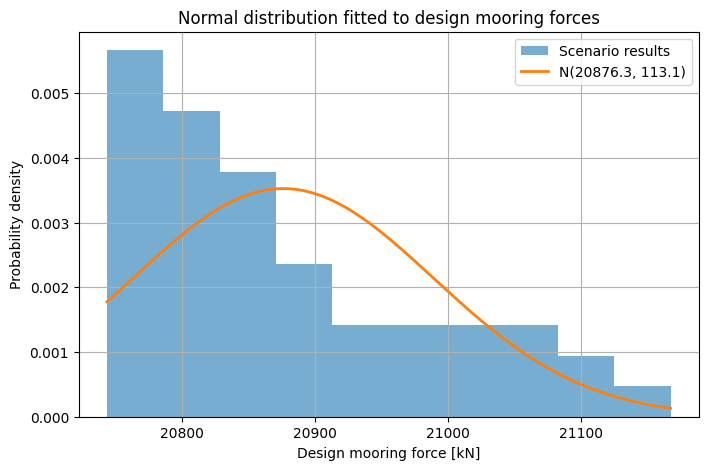

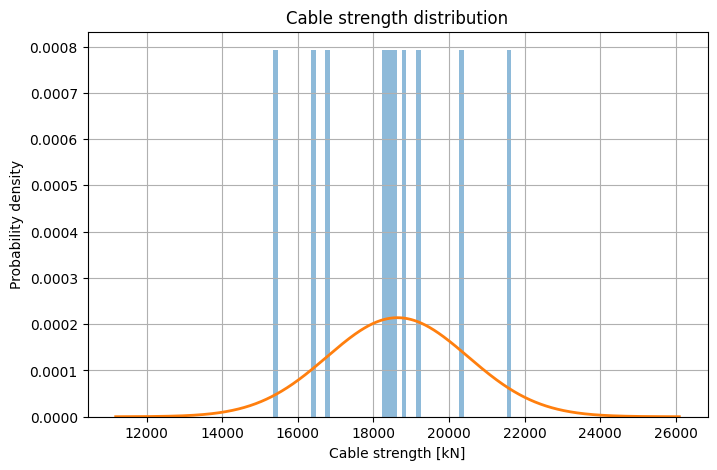

In [18]:
# ============================================================
# Design forces = Fres/2
# ============================================================


# Array met maximale mooringkrachten gedeeld door 2
F_design = df_scenarios["Fres max [kN]"].to_numpy() / 2

print("Design force array [kN]:")
print(F_design)

# Fit normale verdeling
mu, sigma = stats.norm.fit(F_design)

print(f"\nNormal distribution fit:")
print(f"mu    = {mu:.2f} kN")
print(f"sigma = {sigma:.2f} kN")

# Plot histogram + fitted normal distribution
x = np.linspace(
    np.min(F_design),
    np.max(F_design),
    500
)

pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.hist(
    F_design,
    bins=10,
    density=True,
    alpha=0.6,
    label="Scenario results"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label=f"N({mu:.1f}, {sigma:.1f})"
)

plt.xlabel("Design mooring force [kN]")
plt.ylabel("Probability density")
plt.title("Normal distribution fitted to design mooring forces")
plt.grid(True)
plt.legend()
plt.show()

mu_strength = 18639      # kN
sigma_strength = 932*2     # kN (5%*2)

strength_samples = np.random.normal(
    loc=mu_strength,
    scale=sigma_strength,
    size=10
)

x = np.linspace(
    mu_strength - 4*sigma_strength,
    mu_strength + 4*sigma_strength,
    1000
)

pdf = stats.norm.pdf(x, mu_strength, sigma_strength)

plt.figure(figsize=(8,5))
plt.hist(strength_samples, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, linewidth=2)
plt.xlabel("Cable strength [kN]")
plt.ylabel("Probability density")
plt.title("Cable strength distribution")
plt.grid(True)
plt.show()

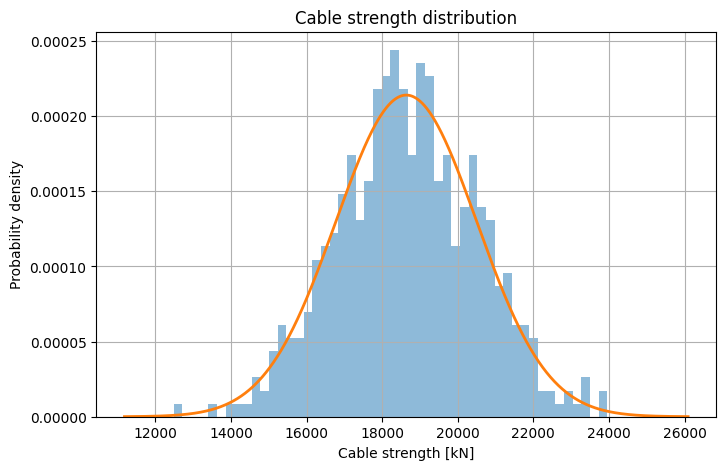

In [19]:


mu_strength = 18639      # kN
sigma_strength = 932*2     # kN (5%*2)

strength_samples = np.random.normal(
    loc=mu_strength,
    scale=sigma_strength,
    size=500
)

x = np.linspace(
    mu_strength - 4*sigma_strength,
    mu_strength + 4*sigma_strength,
    1000
)

pdf = stats.norm.pdf(x, mu_strength, sigma_strength)

plt.figure(figsize=(8,5))
plt.hist(strength_samples, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, linewidth=2)
plt.xlabel("Cable strength [kN]")
plt.ylabel("Probability density")
plt.title("Cable strength distribution")
plt.grid(True)
plt.show()

Load distribution:
mu_load    = 20876.34 kN
sigma_load = 113.15 kN

Strength distribution:
mu_strength    = 18639.00 kN
sigma_strength = 932.00 kN

Probability of failure:
Pf = 0.991310
Pf = 99.131 %


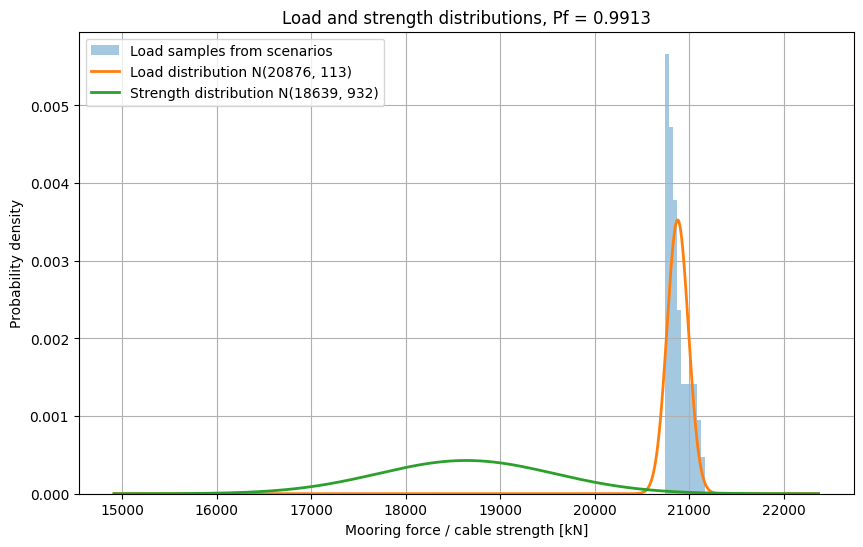

In [31]:
# ============================================================
# Load vs strength distribution + probability of failure
# Pf = P(Load > Strength)
# ============================================================

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# Load distribution
# -----------------------------

F_design = df_scenarios["Fres max [kN]"].to_numpy() / 2

mu_load, sigma_load = stats.norm.fit(F_design)

print("Load distribution:")
print(f"mu_load    = {mu_load:.2f} kN")
print(f"sigma_load = {sigma_load:.2f} kN")

# -----------------------------
# Strength distribution
# -----------------------------

mu_strength = 18639        # kN
sigma_strength = 932    # kN

print("\nStrength distribution:")
print(f"mu_strength    = {mu_strength:.2f} kN")
print(f"sigma_strength = {sigma_strength:.2f} kN")

# -----------------------------
# Probability of failure
# -----------------------------

n_mc = 100000

load_samples = np.random.normal(
    loc=mu_load,
    scale=sigma_load,
    size=n_mc
)

strength_samples = np.random.normal(
    loc=mu_strength,
    scale=sigma_strength,
    size=n_mc
)

failure = load_samples > strength_samples
Pf = np.mean(failure)

print("\nProbability of failure:")
print(f"Pf = {Pf:.6f}")
print(f"Pf = {Pf*100:.3f} %")

# -----------------------------
# Plot both distributions
# -----------------------------

x_min = min(
    mu_load - 4*sigma_load,
    mu_strength - 4*sigma_strength
)

x_max = max(
    mu_load + 4*sigma_load,
    mu_strength + 4*sigma_strength
)

x = np.linspace(x_min, x_max, 2000)

pdf_load = stats.norm.pdf(x, mu_load, sigma_load)
pdf_strength = stats.norm.pdf(x, mu_strength, sigma_strength)

plt.figure(figsize=(10,6))

plt.hist(
    F_design,
    bins=10,
    density=True,
    alpha=0.4,
    label="Load samples from scenarios"
)

plt.plot(
    x,
    pdf_load,
    linewidth=2,
    label=f"Load distribution N({mu_load:.0f}, {sigma_load:.0f})"
)

plt.plot(
    x,
    pdf_strength,
    linewidth=2,
    label=f"Strength distribution N({mu_strength:.0f}, {sigma_strength:.0f})"
)

plt.xlabel("Mooring force / cable strength [kN]")
plt.ylabel("Probability density")
plt.title(f"Load and strength distributions, Pf = {Pf:.4f}")
plt.grid(True)
plt.legend()
plt.show()

Load distribution:
mu_load    = 20876.34 kN
sigma_load = 113.15 kN

Strength lognormal distribution:
5% fractile = 34672.0 kN
median      = 70264.6 kN
mean        = 77051.1 kN
std         = 34673.0 kN
CoV         = 0.450

Probability of failure:
Pf = 0.00229500
Pf = 0.229500 %


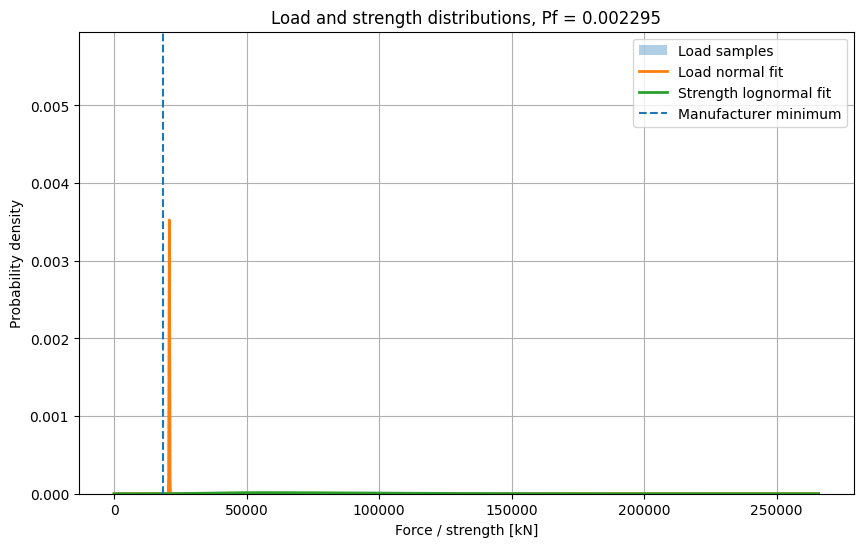

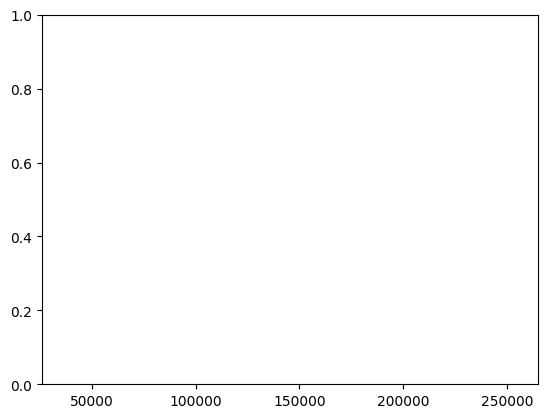

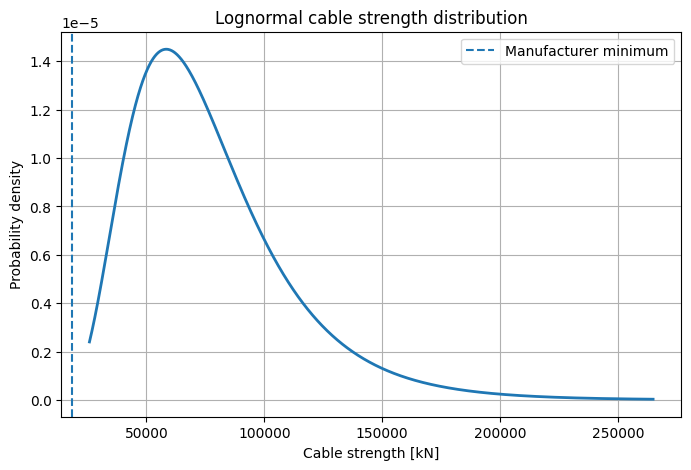

In [28]:
# ============================================================
# Load vs lognormal strength distribution
# Pf = P(Load > Strength)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1. Load distribution from scenario results
# ------------------------------------------------------------

# Maximale mooringkracht gedeeld door 2
F_design = df_scenarios["Fres max [kN]"].to_numpy() / 2

# Fit normale verdeling op de load
mu_load, sigma_load = stats.norm.fit(F_design)

print("Load distribution:")
print(f"mu_load    = {mu_load:.2f} kN")
print(f"sigma_load = {sigma_load:.2f} kN")

# ------------------------------------------------------------
# 2. Lognormal strength distribution
# ------------------------------------------------------------

R_min = 18639       # kN, manufacturer stated minimum strength
p_below = 0.001      # 0.1% kans dat echte sterkte lager is dan R_min

# Grotere CoV geeft langere rechterstaart
cov_strength = 0.45

# Lognormal parameters
sigma_ln = np.sqrt(np.log(1 + cov_strength**2))

# Kies mu_ln zodat P(R < R_min) = p_below
mu_ln = np.log(R_min) - stats.norm.ppf(p_below) * sigma_ln

# Maak lognormal distributie-object
strength_dist = stats.lognorm(
    s=sigma_ln,
    scale=np.exp(mu_ln)
)

# Controlewaarden
mean_strength = strength_dist.mean()
std_strength = strength_dist.std()
median_strength = strength_dist.median()
p5_strength = strength_dist.ppf(0.05)

print("\nStrength lognormal distribution:")
print(f"5% fractile = {p5_strength:.1f} kN")
print(f"median      = {median_strength:.1f} kN")
print(f"mean        = {mean_strength:.1f} kN")
print(f"std         = {std_strength:.1f} kN")
print(f"CoV         = {std_strength/mean_strength:.3f}")

# ------------------------------------------------------------
# 3. Monte Carlo probability of failure
# ------------------------------------------------------------

n_mc = 200000

load_samples = np.random.normal(
    loc=mu_load,
    scale=sigma_load,
    size=n_mc
)

# Voorkom negatieve loads door afkappen op 0
load_samples = np.maximum(load_samples, 0)

strength_samples = strength_dist.rvs(size=n_mc)

failure = load_samples > strength_samples
Pf = np.mean(failure)

print("\nProbability of failure:")
print(f"Pf = {Pf:.8f}")
print(f"Pf = {Pf*100:.6f} %")

# ------------------------------------------------------------
# 4. Plot load and strength distribution in one figure
# ------------------------------------------------------------

x_min = 0
x_max = max(
    np.percentile(load_samples, 99.9),
    np.percentile(strength_samples, 99.9)
)

x = np.linspace(x_min, x_max, 2000)

pdf_load = stats.norm.pdf(x, mu_load, sigma_load)
pdf_strength = strength_dist.pdf(x)

plt.figure(figsize=(10,6))

# Scenario load histogram
plt.hist(
    F_design,
    bins=10,
    density=True,
    alpha=0.35,
    label="Load samples"
)

# Load normal fit
plt.plot(
    x,
    pdf_load,
    linewidth=2,
    label="Load normal fit"
)

# Strength lognormal fit
plt.plot(
    x,
    pdf_strength,
    linewidth=2,
    label="Strength lognormal fit"
)

# Manufacturer minimum
plt.axvline(
    R_min,
    linestyle="--",
    linewidth=1.5,
    label="Manufacturer minimum"
)

plt.xlabel("Force / strength [kN]")
plt.ylabel("Probability density")
plt.title(f"Load and strength distributions, Pf = {Pf:.6f}")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 5. Plot strength distribution only
# ------------------------------------------------------------

x_strength = np.linspace(
    18000,
    strength_dist.ppf(0.999),
    2000
)
xmin = strength_dist.ppf(0.01)
xmax = strength_dist.ppf(0.999)

x_strength = np.linspace(xmin, xmax, 2000)

plt.xlim(xmin, xmax)

pdf_strength_only = strength_dist.pdf(x_strength)

plt.figure(figsize=(8,5))

plt.plot(
    x_strength,
    pdf_strength_only,
    linewidth=2
)

plt.axvline(
    R_min,
    linestyle="--",
    linewidth=1.5,
    label="Manufacturer minimum"
)

plt.xlabel("Cable strength [kN]")
plt.ylabel("Probability density")
plt.title("Lognormal cable strength distribution")
plt.grid(True)
plt.legend()
plt.show()